# Zones
<div>
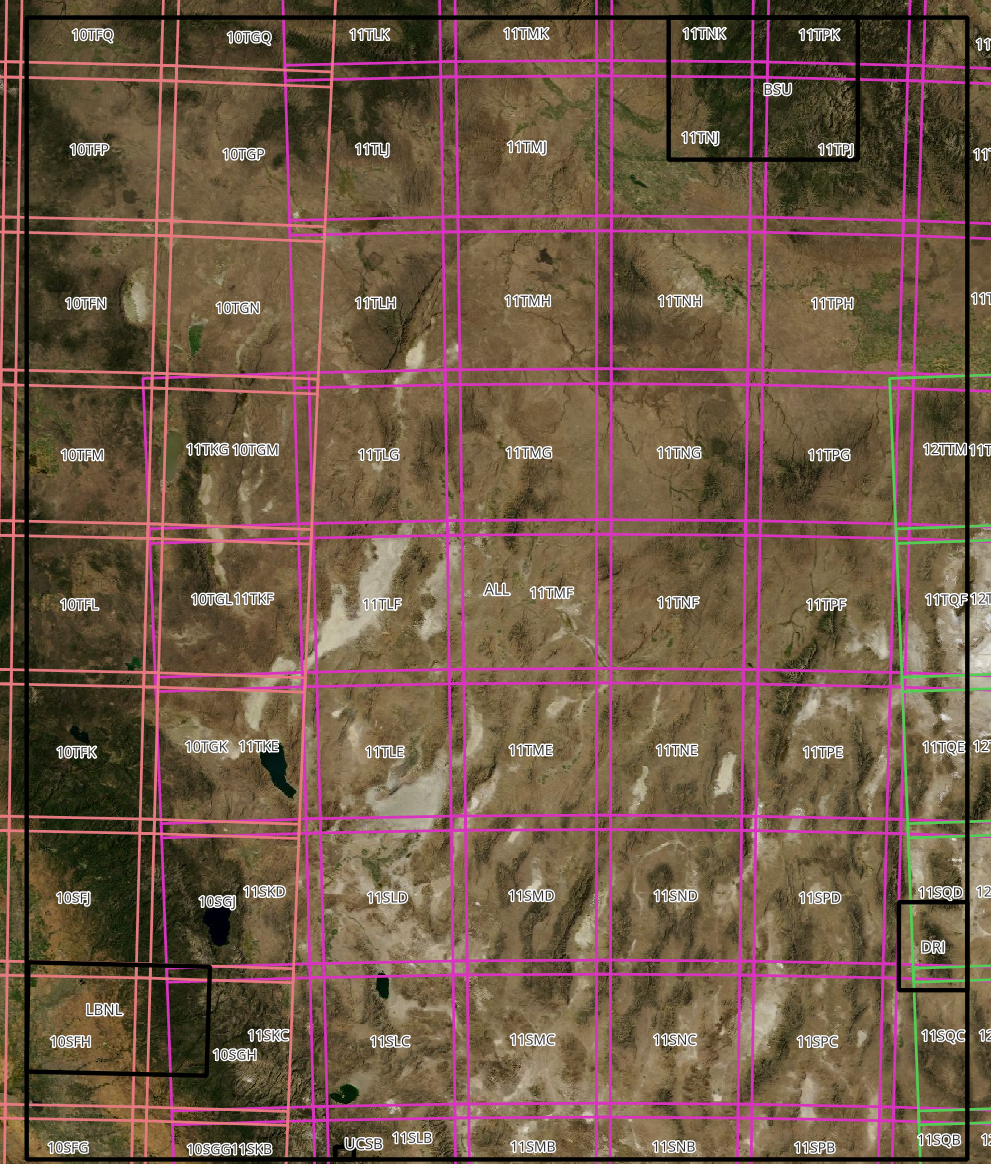
</div>
 

## UCSB
- Zone 11
- Tiles: 11SLB

## LBNL
- Zone 10
- Tiles: **10SFH, 10SGH**, (10SFJ, 10SGJ, 11SKD, 11SKC)
  
## DRI
- Zone 11
- Tiles: **11SQD, 11SQC**, (12STJ, 12STH)

## BSU
- Zone 11
- Tiles: **11TNK, 11TNJ, 11TPK, 11TPJ**

- Coordinates are pixel centers

In [1]:
import geopandas
import pandas
import zarr
import xarray
import numpy as np
import dask
import dask.distributed
import pyproj
import matplotlib.pyplot as plt

In [2]:
region = 'fairbanks'

if region == 'UCSB':
    tiles = ['11SLB']
elif region == 'DRI':
    tiles =  ['11SQD', '11SQC']
elif region == 'LBNL':
    tiles = ['10SFH', '10SGH']
elif region == 'BSU':
    tiles = ['11TNK', '11TNJ', '11TPK', '11TPJ']
elif region == 'fairbanks':
    tiles = ['06WVT', '06WWT', '06WVS', '06WWS']
    #tiles = ['06WVT', '06WWT', '06WXT', '06WVS', '06WWS', '06WXS']

1. read in all tiles
1. rechunk band
1. combine

# Read tiles

In [3]:
dss10 = {}
dss20 = {}
for tile in tiles:
    zarr_store_10m = f'/data/sentinel2/zarrs_v3/{tile}_10m.zarr'    
    zarr_store_20m = f'/data/sentinel2/zarrs_v3/{tile}_20m.zarr'    
    ds10 = xarray.open_zarr(zarr_store_10m, consolidated=False)
    ds20 = xarray.open_zarr(zarr_store_20m, consolidated=False)
    dss10[tile] = ds10
    dss20[tile] = ds20

# Subsetting to ROI

In [4]:
crs_string= dss10[tiles[0]]['spatial_ref'].projected_crs_name
crs = pyproj.CRS(crs_string)
epsg = crs.to_epsg()

In [5]:
# ROIs from the tristate project
path = '/data/shapes/tristate_rois.gpkg'
rois = geopandas.read_file(path)
roi = rois[rois['name'] == region]

ERROR 1: PROJ: proj_create_from_database: Open of /home/griessban/.conda/envs/spipy14/share/proj failed


In [6]:
path = '/data/arctic_cso/domains/fairbanks_aoi.shp'
roi = geopandas.read_file(path)

In [7]:
bounds = roi.to_crs(epsg).buffer(50).iloc[0].bounds
minx, miny, maxx, maxy = bounds

In [8]:
for tile in tiles:   
    dss10[tile] = dss10[tile].sel(x=slice(minx, maxx), y=slice(maxy, miny),
                                  x_angles=slice(minx-2500, maxx+2500), y_angles=slice(maxy+2500, miny-2500))

    dss20[tile] = dss20[tile].sel(x=slice(minx, maxx), y=slice(maxy, miny),
                                  x_angles=slice(minx-2500, maxx+2500), y_angles=slice(maxy+2500, miny-2500))

# Dealing with detectors
... since the tiles are generated by the same overpass, the same tile will always be observed by the same detectors, which may be differing from the detectors observing the neighboring tiles

In [9]:
detectors10 = set()
detectors20 = set()
for tile in tiles:
    detectors10 = detectors10.union(set(dss10[tile].detector.to_numpy()))
    detectors20 = detectors20.union(set(dss20[tile].detector.to_numpy()))

detectors10 = sorted(list(detectors10))
detectors20 = sorted(list(detectors20))

In [10]:
for tile in tiles:
    dss10[tile] = dss10[tile].reindex(detector=detectors10)
    dss20[tile] = dss20[tile].reindex(detector=detectors20)

# Unify Times across tiles
1. find intersection of timesteps that exist in all tiles
1. cut to intersection

In [11]:
# Set to timesteps of first 10m tile
rounded = '5d'
times = set(dss10[tiles[0]].time.dt.round(rounded).values)

# Make intersection with all other 10m tiles
for tile, ds in dss10.items():
    times = times.intersection(ds.time.dt.round(rounded).values)    

# Make intersection with all 20m tiles
for tile, ds in dss20.items():
    times = times.intersection(ds.time.dt.round(rounded).values)    

# Those are timesteps available in all tiles 
times = sorted(np.array(list(times)))
len(times)

463

In [12]:
for tile in tiles:
    dss10[tile] = dss10[tile].sel(time=times, method='nearest')    
    dss20[tile] = dss20[tile].sel(time=times, method='nearest')    

In [13]:
for tile in tiles:
    dss10[tile]['time_actual'] = dss10[tile]['time']
    dss20[tile]['time_actual'] = dss20[tile]['time']
    dss10[tile]['time'] = dss10[tile].time.dt.round(rounded)
    dss20[tile]['time'] = dss20[tile].time.dt.round(rounded)

# Trim Tiles to cut overlap 

In [ ]:
import xarray as xr

def merge_tiles_priority(datasets, xy):
    """
    Merge tiles where earlier datasets in the list take priority in overlaps.
    Non-NaN values are preserved.
    """
    angles = ['sun_azimuth_grid', 'sun_zenith_grid', 'viewing_azimuth_grid', 'viewing_zenith_grid']
    
    # Start with the first dataset
    combined1 = datasets[priority_order[0]][xy].copy()
    combined2 = datasets[priority_order[0]][angles].copy()
        
    # Merge each subsequent dataset, filling NaNs in result
    for tile_name in priority_order[1:]:
        ds1 = datasets[tile_name][xy]
        ds2 = datasets[tile_name][angles]
        # Where result is NaN, use values from ds
        combined1 = combined1.combine_first(ds)

    combined = xarray.merge([combined1, combined2, combined1['spatial_ref']])
    
    return combined


xy10 = ['AOT', 'WVP', 'reflectance']
xy20 = ['CLD', 'SCL', 'SNW', 'WVP', 'reflectance']

dss10_ = merge_tiles_priority(dss10, xy10).isel(y=[None, None, -1])
dss20_ = merge_tiles_priority(dss10, xy20).isel(y=[None, None, -1])


In [14]:
def trim_tile_overlaps(dss_dict, tiles_grid, coord_dims=['x', 'y'], 
                       angle_dims=['x_angles', 'y_angles'], buffer=10):
    """
    Trim overlapping edges from a grid of tiles.
    
    Parameters:
    -----------
    dss_dict : dict
        Dictionary mapping tile names to xarray datasets
    tiles_grid : list of lists
        2D list representing tile arrangement, e.g.:
        [['06WVT', '06WWT', '06WXT'],
         ['06WVS', '06WWS', '06WXS']]
    coord_dims : list
        Coordinate dimensions to trim (e.g., ['x', 'y'])
    angle_dims : list
        Angle coordinate dimensions to trim (e.g., ['x_angles', 'y_angles'])
    buffer : int
        Buffer to add when cutting coordinates (default: 10)
    
    Returns:
    --------
    dict : Dictionary with trimmed datasets
    """
    import copy
    result = copy.deepcopy(dss_dict)
    
    n_rows = len(tiles_grid)
    n_cols = len(tiles_grid[0])
    
    # Trim horizontal overlaps (keep left column, trim right columns)
    for col_idx in range(1, n_cols):
        # Use leftmost column as reference
        ref_tile = tiles_grid[0][0]
        
        # Find split points from the previous column
        prev_col_tile = tiles_grid[0][col_idx - 1]
        x_split = result[prev_col_tile].x.max() + buffer
        x_angles_split = result[prev_col_tile].x.max()
        
        # Trim all tiles in current column
        for row_idx in range(n_rows):
            tile = tiles_grid[row_idx][col_idx]
            if tile in result:
                result[tile] = result[tile].sel(
                    x=slice(x_split, None),
                    x_angles=slice(x_angles_split, None)
                )
    
    # Trim vertical overlaps (keep top row, trim bottom rows)
    for row_idx in range(1, n_rows):
        # Use top row as reference
        ref_tile = tiles_grid[0][0]
        
        # Find split points from the previous row
        prev_row_tile = tiles_grid[row_idx - 1][0]
        y_split = result[prev_row_tile].y.min() - buffer
        y_angles_split = result[prev_row_tile].y_angles.min()
        
        # Trim all tiles in current row
        for col_idx in range(n_cols):
            tile = tiles_grid[row_idx][col_idx]
            if tile in result:
                result[tile] = result[tile].sel(
                    y=slice(y_split, None),
                    y_angles=slice(y_angles_split, None)
                )
    
    return result

In [15]:
## BSU
tiles_grid = [
    ['11TNK', '11TPK'],
    ['11TNJ', '11TPJ']
]

# DRI
tiles_grid = [
    ['11SQD'],
    ['11SQC'],
]

# LBNL
tiles_grid = [
    ['10SFH', '10SGH']
]

# UCSB 
tiles_grid = [
    ['11SLB']
]

# Fairbanks
tiles_grid = [
    ['06WVT', '06WWT'],
    ['06WVS', '06WWS']
]

dss10_trimmed = trim_tile_overlaps(dss10, tiles_grid)
dss20_trimmed = trim_tile_overlaps(dss20, tiles_grid)

# Combine the DS
Multiple options here:
- `xarray.combine_by_coords([ds1, ds2], combine_attrs='drop')` seems like the correct tool. But we have to split x/yangles coordinates.
- `ds1.combine_first(ds2)`. Struggle with the chunk size and may bloat memory. But the good part is that we don't need to slice the overlapping coordinates
- `xarray.concat([ds1, ds2], dim=('x'))`. Also requires to split x/yangles. Also will create arificial coordinates

In [16]:
xy10 = ['AOT', 'WVP', 'reflectance']
xy20 = ['CLD', 'SCL', 'SNW', 'WVP', 'reflectance']
angles = ['sun_azimuth_grid', 'sun_zenith_grid', 'viewing_azimuth_grid', 'viewing_zenith_grid']

In [17]:
combined10_1 = xarray.combine_by_coords([ds[xy10] for ds in dss10_trimmed.values()], combine_attrs='override', join='outer')
combined10_2 = xarray.combine_by_coords([ds[angles] for ds in dss10_trimmed.values()], combine_attrs='override', join='outer')
combined10 = xarray.merge([combined10_1, combined10_2, dss10_trimmed[tiles[0]]['spatial_ref']])

combined20_1 = xarray.combine_by_coords([ds[xy20] for ds in dss20_trimmed.values()], combine_attrs='override', join='outer')
combined20_2 = xarray.combine_by_coords([ds[angles] for ds in dss20_trimmed.values()], combine_attrs='override', join='outer')
combined20 = xarray.merge([combined20_1, combined20_2, dss20_trimmed[tiles[0]]['spatial_ref']])

# Subset to ROI
adjust the buffer heres to good chunk sizes

In [18]:
bounds = roi.to_crs(epsg).buffer(-30).iloc[0].bounds

minx, miny, maxx, maxy = bounds

In [19]:
minx20 = combined20.sel(x=minx, method='ffill').x
minx10 = combined10.sel(x=minx20, method='ffill').x

if maxx > combined20.x.max():
    maxx20 = combined20.x.max()
else:
    maxx20 = combined20.sel(x=maxx, method='bfill').x
maxx10 = combined10.sel(x=maxx20, method='bfill').x

miny20 = combined20.sel(y=miny, method='bfill').y
miny10 = combined10.sel(y=miny20, method='bfill').y

maxy20 = combined20.sel(y=maxy, method='ffill').y
maxy10 = combined10.sel(y=maxy20, method='ffill').y

In [20]:
combined10 = combined10.sel(x=slice(minx10, maxx10), y=slice(maxy10, miny10),
                x_angles=slice(minx10-2500, maxx10+2500), y_angles=slice(maxy10+2500, miny10-2500))

In [21]:
combined20 = combined20.sel(x=slice(minx20, maxx20), y=slice(maxy20, miny20),
                x_angles=slice(minx20-2500, maxx20+2500), y_angles=slice(maxy20+2500, miny20-2500))

# Determine chunksizes

In [22]:
def prime_factors(n):
    factors = []
    divisor = 2
    while n > 1:
        if n % divisor == 0:
            factors.append(divisor)
            n //= divisor  # Use integer division
        else:
            divisor += 1
    return factors

In [23]:
def get_chunksize(length):
    factors = prime_factors(length)
    print(factors)
    chunk = 1
    i = 1
    while chunk < 600 and i <=len(factors):
        chunk *= factors[0-i]
        i += 1
    return chunk    

In [24]:
chunk_y = get_chunksize(len(combined10.y))
chunk_x = get_chunksize(len(combined10.x))
chunk_y, chunk_x

[2, 2, 3, 23, 53]
[2, 2, 2, 2, 2, 569]


(1219, 1138)

In [25]:
for var in combined10.data_vars:
    del combined10[var].encoding['preferred_chunks']
    if 'chunks' in combined10[var].encoding:
        del combined10[var].encoding['chunks']
        
        
for var in combined20.data_vars:
    del combined20[var].encoding['preferred_chunks']
    if 'chunks' in combined20[var].encoding:        
        del combined20[var].encoding['chunks']

In [26]:
combined10 = combined10.sortby('time')
combined10 = combined10.transpose('time', 'band', 'detector', 'y', 'x', 'y_angles', 'x_angles')
combined10 = combined10.chunk(time=1, y=chunk_y, x=chunk_x, band=-1, y_angles=-1, x_angles=-1, detector=-1)

combined20 = combined20.sortby('time')
combined20 = combined20.transpose('time', 'band', 'detector', 'y', 'x', 'y_angles', 'x_angles')
combined20 = combined20.chunk(time=1, y=chunk_y, x=chunk_x, band=-1, y_angles=-1, x_angles=-1, detector=-1)

In [27]:
combined10['reflectance']

<xarray.DataArray 'reflectance' (time: 463, band: 4, y: 14628, x: 18208)> Size: 2TB
dask.array<rechunk-merge, shape=(463, 4, 14628, 18208), dtype=float32, chunksize=(1, 4, 1219, 1138), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 2015-10-22 2016-02-09 ... 2025-03-13
  * band     (band) object 32B 'B2' 'B3' 'B4' 'B8'
  * y        (y) float64 117kB 7.289e+06 7.289e+06 ... 7.142e+06 7.142e+06
  * x        (x) float64 146kB 4.277e+05 4.277e+05 ... 6.098e+05 6.098e+05
Attributes: (12/84)
    AOT_QUANTIFICATION_VALUE:              1000.0
    AOT_QUANTIFICATION_VALUE_UNIT:         none
    AOT_RETRIEVAL_ACCURACY:                0.0
    AOT_RETRIEVAL_METHOD:                  CAMS
    BOA_QUANTIFICATION_VALUE:              10000
    BOA_QUANTIFICATION_VALUE_UNIT:         none
    ...                                    ...
    viewing_zenith_mean_B10:               2.77900768636106
    viewing_azimuth_mean_B10:              167.760731878817
    viewing_zenith_mean_B11:               2.95289863774776
    viewing_azimuth_mean_B11:              167.182153097404
    viewing_zenith_mean_B12:               3.14817413170569
    viewing_azimuth_mean_B12:              166.725237253648

In [29]:
combined20

<xarray.Dataset> Size: 1TB
Dimensions:               (time: 463, y: 7314, x: 9104, band: 6, y_angles: 32,
                           x_angles: 38, detector: 12)
Coordinates:
  * time                  (time) datetime64[ns] 4kB 2015-10-22 ... 2025-03-13
  * y                     (y) float64 59kB 7.289e+06 7.289e+06 ... 7.142e+06
  * x                     (x) float64 73kB 4.277e+05 4.277e+05 ... 6.098e+05
  * band                  (band) object 48B 'B11' 'B12' 'B5' 'B6' 'B7' 'B8A'
  * y_angles              (y_angles) float64 256B 7.29e+06 ... 7.14e+06
  * x_angles              (x_angles) float64 304B 4.3e+05 4.35e+05 ... 6.1e+05
  * detector              (detector) object 96B '1' '10' '11' ... '7' '8' '9'
Data variables:
    CLD                   (time, y, x) uint16 62GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    SCL                   (time, y, x) uint16 62GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    SNW                   (time, y, x) uint16 62GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    WVP                   (time, y, x) float32 123GB dask.array<chunksize=(1, 1219, 1138), meta=np.ndarray>
    reflectance           (time, band, y, x) float32 740GB dask.array<chunksize=(1, 6, 1219, 1138), meta=np.ndarray>
    sun_azimuth_grid      (time, y_angles, x_angles) float32 2MB dask.array<chunksize=(1, 32, 38), meta=np.ndarray>
    sun_zenith_grid       (time, y_angles, x_angles) float32 2MB dask.array<chunksize=(1, 32, 38), meta=np.ndarray>
    viewing_azimuth_grid  (time, band, detector, y_angles, x_angles) float32 162MB dask.array<chunksize=(1, 6, 12, 32, 38), meta=np.ndarray>
    viewing_zenith_grid   (time, band, detector, y_angles, x_angles) float32 162MB dask.array<chunksize=(1, 6, 12, 32, 38), meta=np.ndarray>
    spatial_ref           int64 8B ...
Attributes: (12/84)
    AOT_QUANTIFICATION_VALUE:              1000.0
    AOT_QUANTIFICATION_VALUE_UNIT:         none
    AOT_RETRIEVAL_ACCURACY:                0.0
    AOT_RETRIEVAL_METHOD:                  CAMS
    BOA_QUANTIFICATION_VALUE:              10000
    BOA_QUANTIFICATION_VALUE_UNIT:         none
    ...                                    ...
    viewing_zenith_mean_B10:               2.77900768636106
    viewing_azimuth_mean_B10:              167.760731878817
    viewing_zenith_mean_B11:               2.95289863774776
    viewing_azimuth_mean_B11:              167.182153097404
    viewing_zenith_mean_B12:               3.14817413170569
    viewing_azimuth_mean_B12:              166.725237253648

/home/griessban/.conda/envs/spipy14/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in power
  return self.func(*new_argspec)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2450436].


CPU times: user 16 s, sys: 12.2 s, total: 28.2 s
Wall time: 4.68 s


(np.float64(427700.0),
 np.float64(609700.0),
 np.float64(7142540.0),
 np.float64(7288740.0))

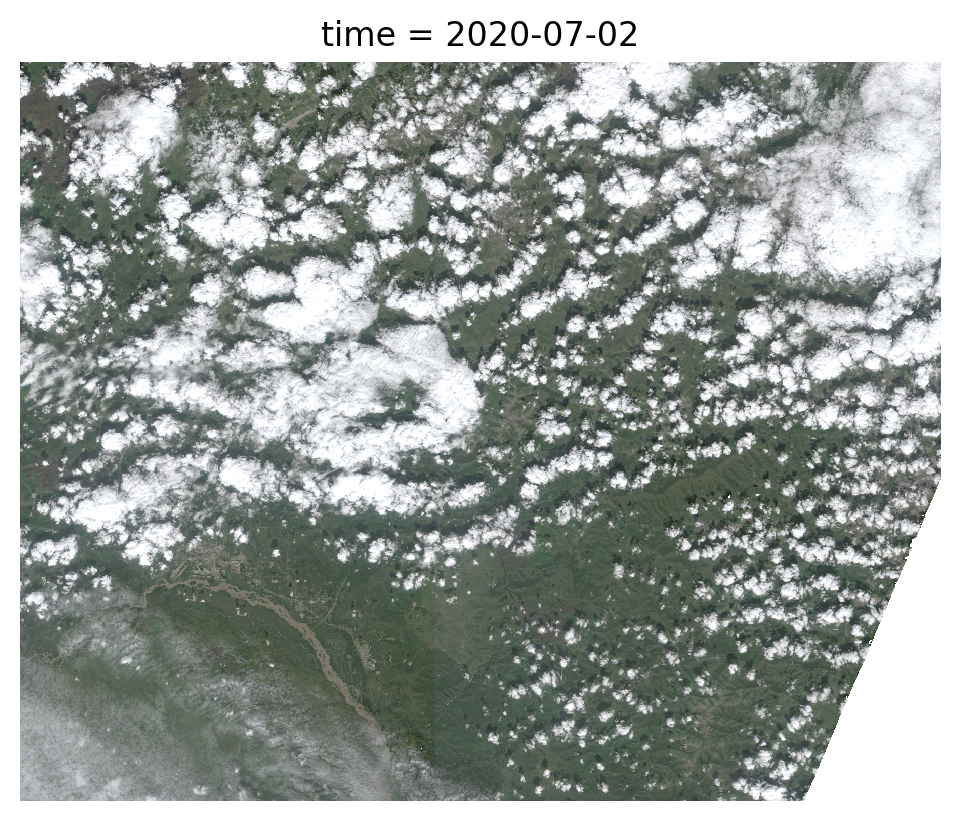

In [30]:
%%time
fig, ax = plt.subplots(dpi=200)

gamma = 3
plottable = (combined10.isel(time=205)['reflectance'].sel(band=['B4', 'B3', 'B2']).coarsen(x=10, y=10, boundary='trim').mean()**(1/gamma)).squeeze()
plottable.plot.imshow(ax=ax, alpha=1)

#combined10['sun_zenith_grid'].isel(time=264).plot.imshow(ax=ax, alpha=1)

ax.set_aspect('equal')
ax.axis('off')

# Writing Zarr

In [31]:
from dask.distributed import LocalCluster
import dask.distributed
import logging

dask.config.set({'temporary-directory': '/data/dask'})
dask.config.set({'distributed.comm.timeouts.tcp': '3600s'})
dask.config.set({'distributed.comm.timeouts.connect': '3600s'})
dask.config.get('distributed.comm.timeouts')
dask.config.set({"logging.distributed.worker": "ERROR"})

cluster = dask.distributed.LocalCluster(n_workers=32, 
                                        threads_per_worker=2, # Good question ... 
                                        memory_limit='64GB', 
                                        processes=True,  # Probably a good idea here
                                        dashboard_address='localhost:8787',
                                        silence_logs="ERROR")

client = dask.distributed.Client(cluster) 

In [32]:
%%time    
zarr_store10 = f'/scratch/sentinel2_arctic/{region}_10m.zarr'
zarr_store20 = f'/scratch/sentinel2_arctic/{region}_20m.zarr'

combined10.to_zarr(zarr_store10, mode='w', zarr_format=3, consolidated=False)  
combined20.to_zarr(zarr_store20, mode='w', zarr_format=3, consolidated=False)  

/home/griessban/.conda/envs/spipy14/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 179.84 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/griessban/.conda/envs/spipy14/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 112.21 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 1h 15min 5s, sys: 32min, total: 1h 47min 5s
Wall time: 3h 30min 32s


In [33]:
client.close()
cluster.close()

In [ ]:
1